In [1]:
import os
import numpy as np
import pymc as pm
import pytensor
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
if os.environ.get("SIMPLEVI_PYTENSOR_CXX"):
    pytensor.config.cxx = os.environ["SIMPLEVI_PYTENSOR_CXX"]
from tqdm.notebook import tqdm

from modulars.distributions import gaussian_multid, gaussian_multid_posterior, ensure_arr
from modulars.utils import check_all_int_or_float_or_1darrays, check_all_covar_shaped_arrays
from modulars.pymc_rr_test import run_single_seed_pymc_VI, run_pymc_VI

In [ ]:
# this is 40 dimensions
mu_prior = np.zeros(40)
sigma_prior = np.ones(40) * 10 # diag std of prior
mu_like = 2.0
sigma_like = 1.0 # std of likelihood
max_iters = 50_000
n_obs = 3
dim = 40
np.random.seed(42)

DIAG = True

# Generate observations for each dimension
observed_data = gaussian_multid(
    seed=42, n_samples=n_obs, mu_like=mu_like,
    scale_like=sigma_like, dim=dim)
# compute known posterior, this is the posterior diagonal standard deviation vector as true_sigma_post
true_mu_post, true_sigma_post = gaussian_multid_posterior(
    observed_data, n_samples=n_obs,
    mu_prior=mu_prior, scale_prior=sigma_prior**2,
    scale_like=1.0, std_devs=False,
    diag=DIAG, dim=40)

In [3]:
def run_model(n_mc_samples = 1, optimizer = 'default', seed = 1):
    with pm.Model() as model:
        mu = pm.Normal('mu', mu_prior, sigma_prior, shape=dim)
        likelihood = pm.Normal('y', mu, sigma=np.ones(dim), observed=observed_data)
        
        tracked_vals = run_pymc_VI(model, n_mc_samples, 50_000, optimizer, seed, SINGLE_DIM=False)
    return tracked_vals


In [4]:
results = []
adam_results = []
for seed in tqdm(range(10)):
    all_results = run_single_seed_pymc_VI(seed, run_model)
    results.append(all_results[0])
    adam_results.append(all_results[1])

  0%|          | 0/10 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 260.64
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.63
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.37
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.62
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.37
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.66
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.37
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.62
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.37
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.69
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.37
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.66
Finished [100%]: Average 

In [5]:
%matplotlib inline
from modulars.utils import apply_traj_transform_multid
single_means, single_covs, multi_means, multi_covs = \
    apply_traj_transform_multid(results, PYMC=True)

adam_single_means, adam_single_covs, adam_multi_means, adam_multi_covs = \
    apply_traj_transform_multid(adam_results, PYMC=True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [6]:
single_means.shape, single_covs.shape, multi_means.shape, multi_covs.shape

((10, 50000, 40), (10, 50000, 40), (10, 50000, 40), (10, 50000, 40))

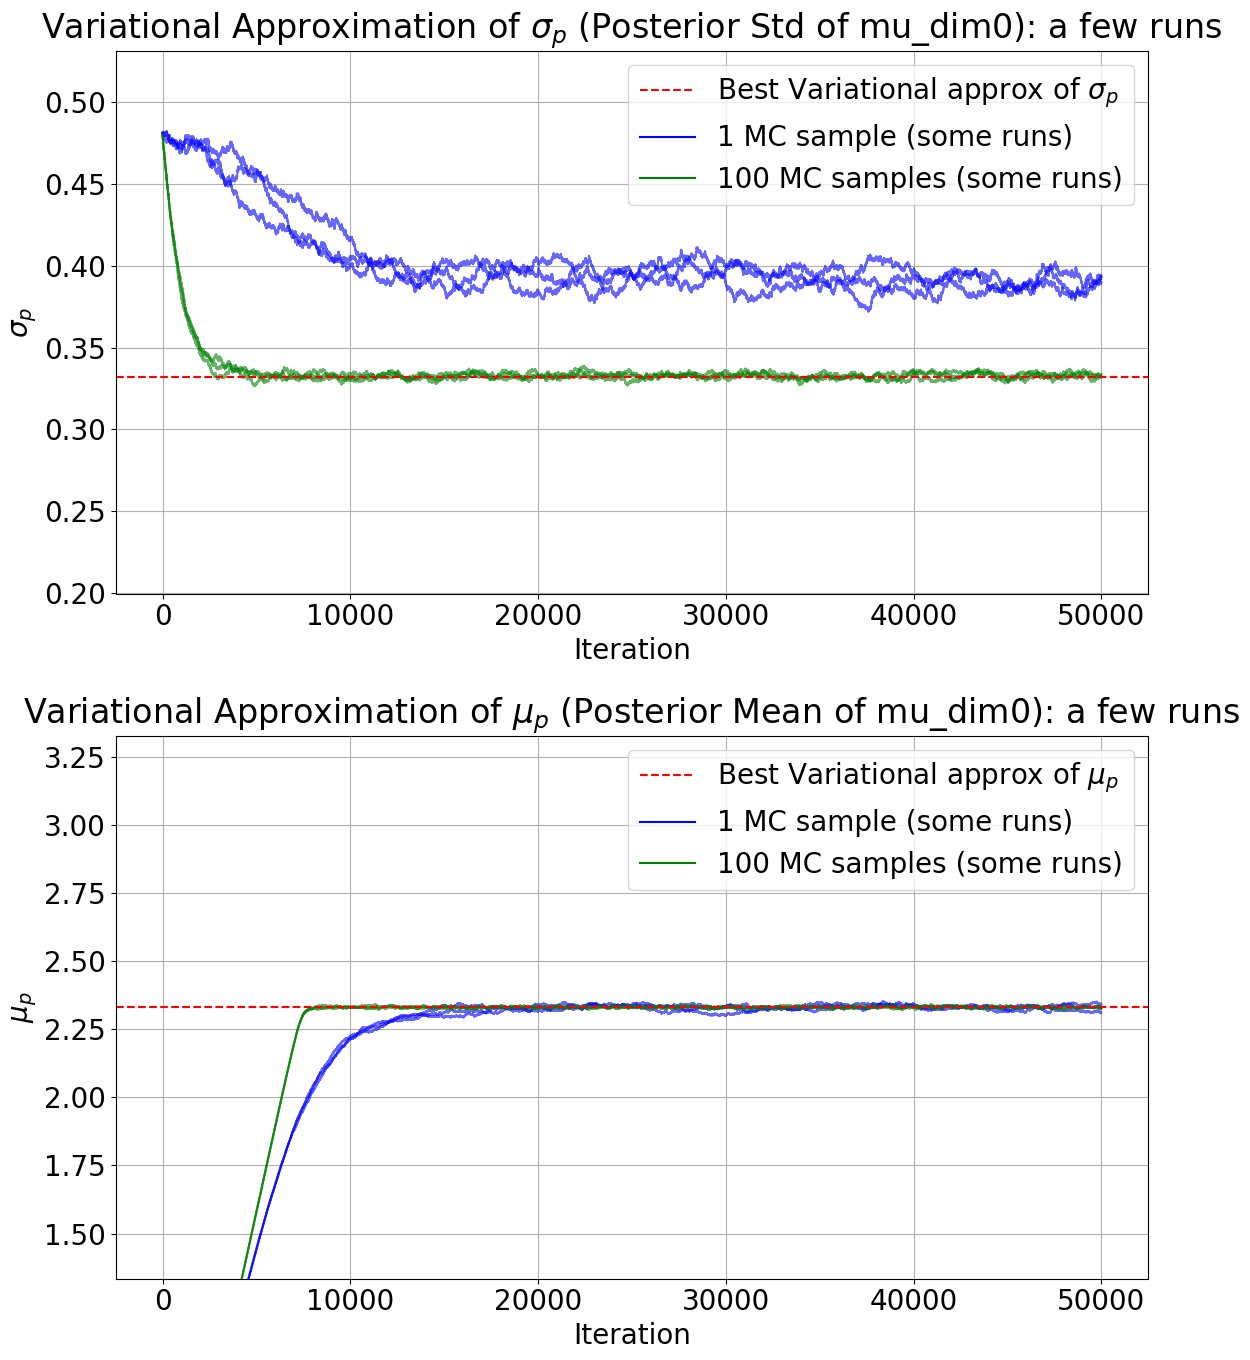

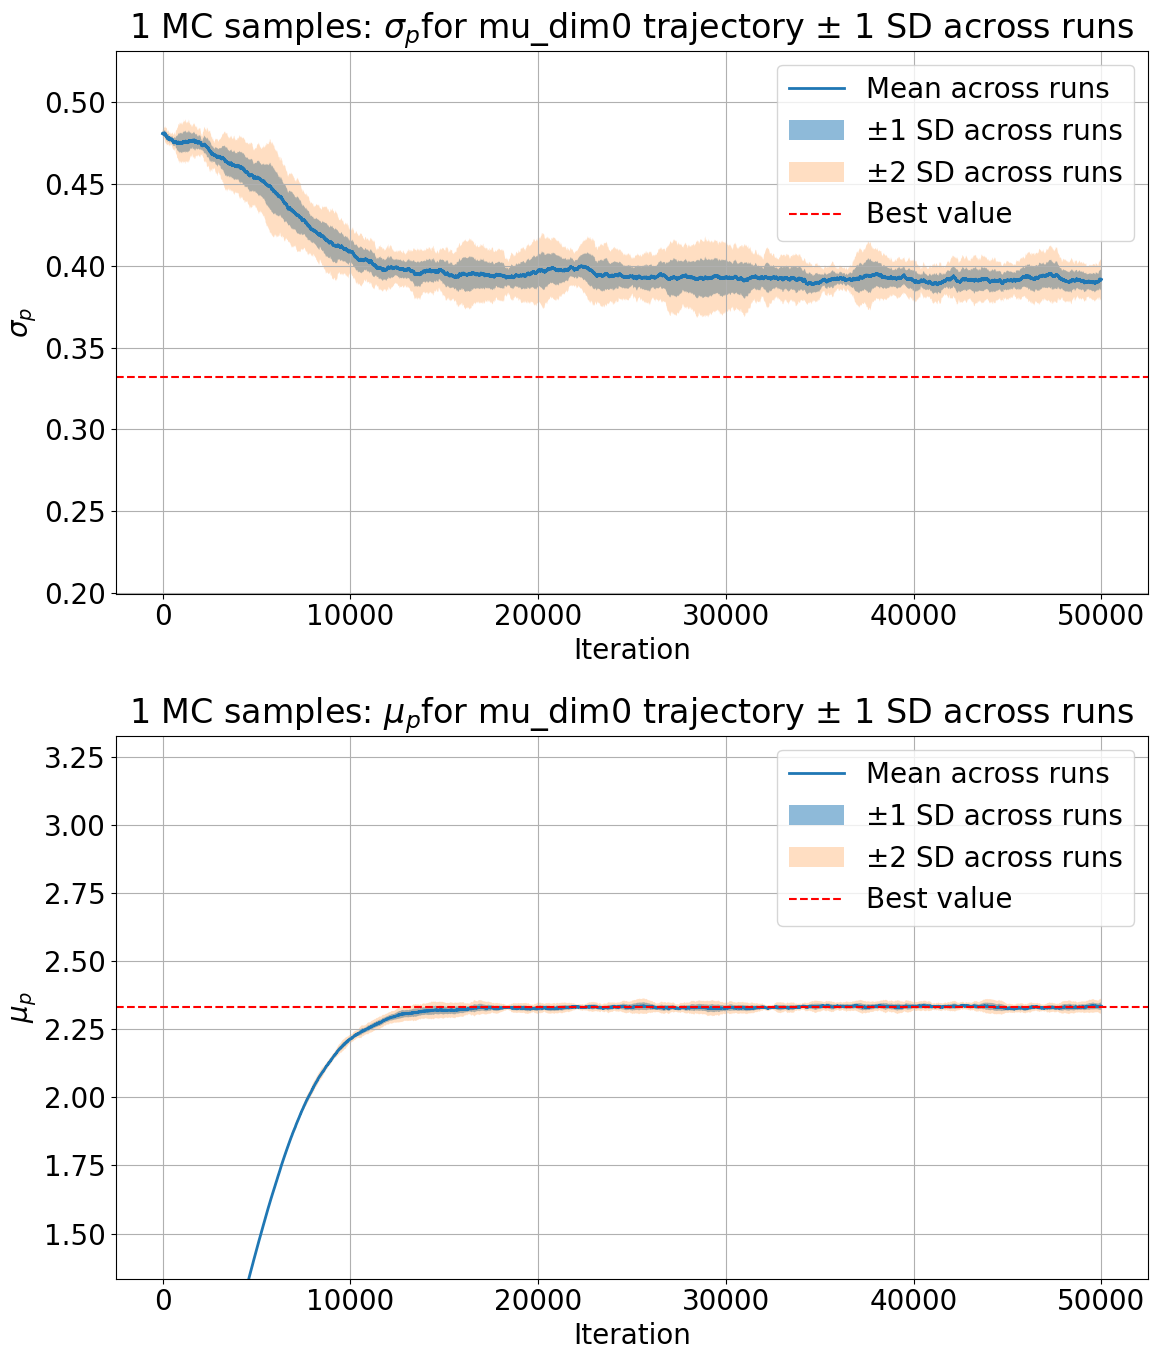

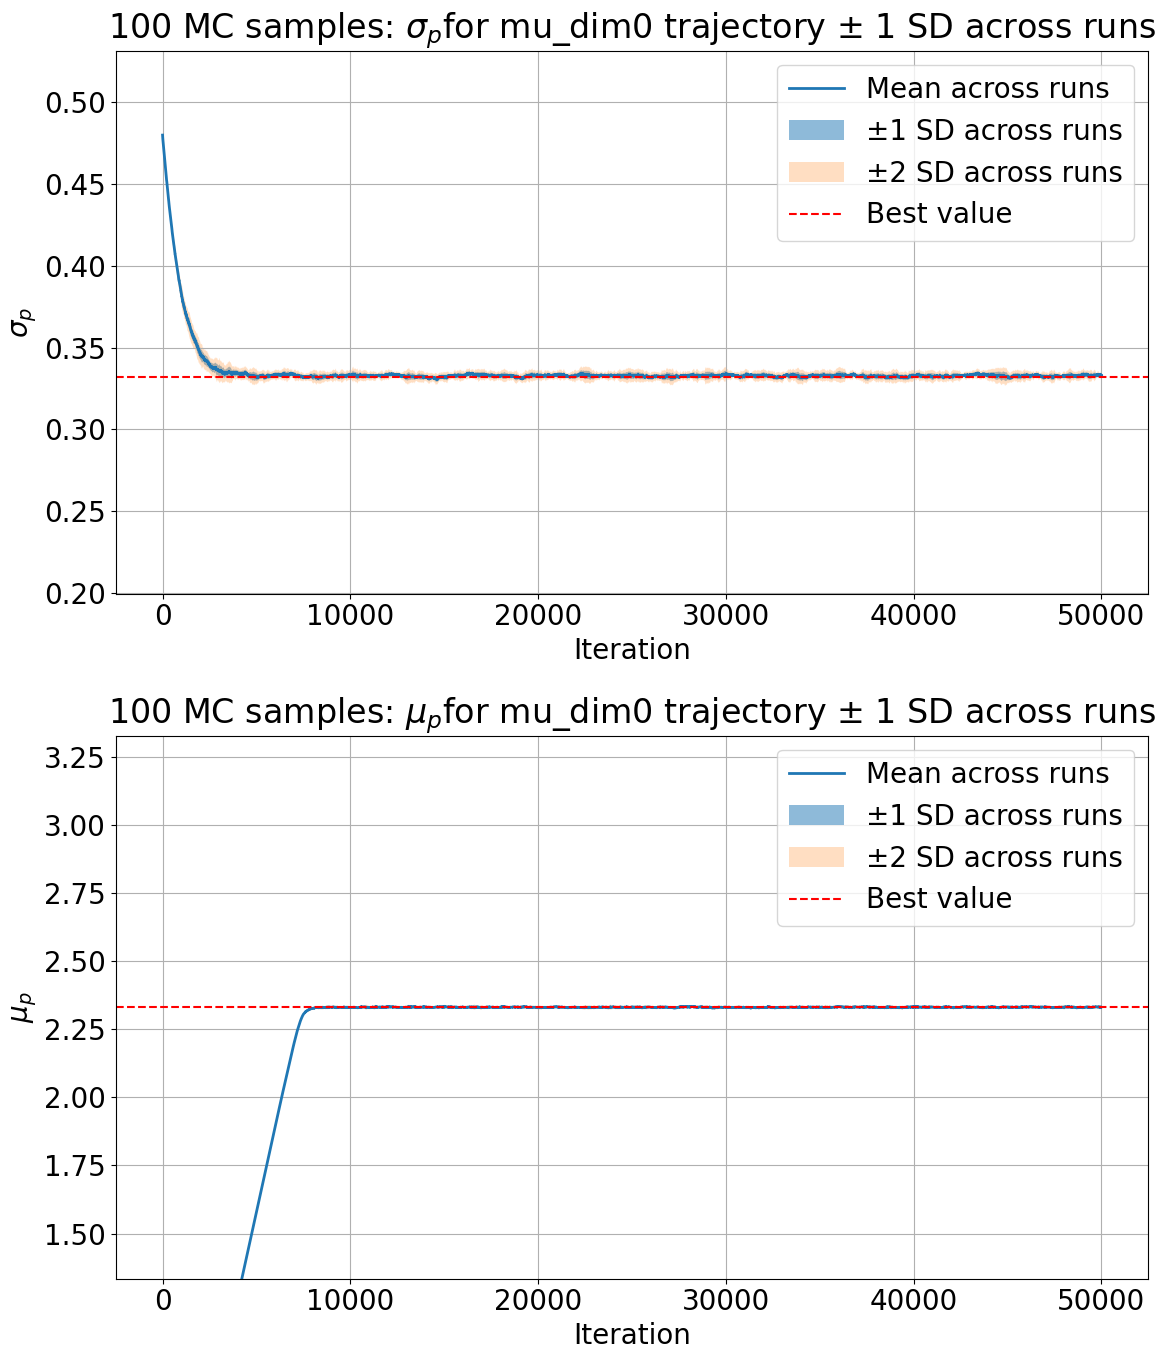

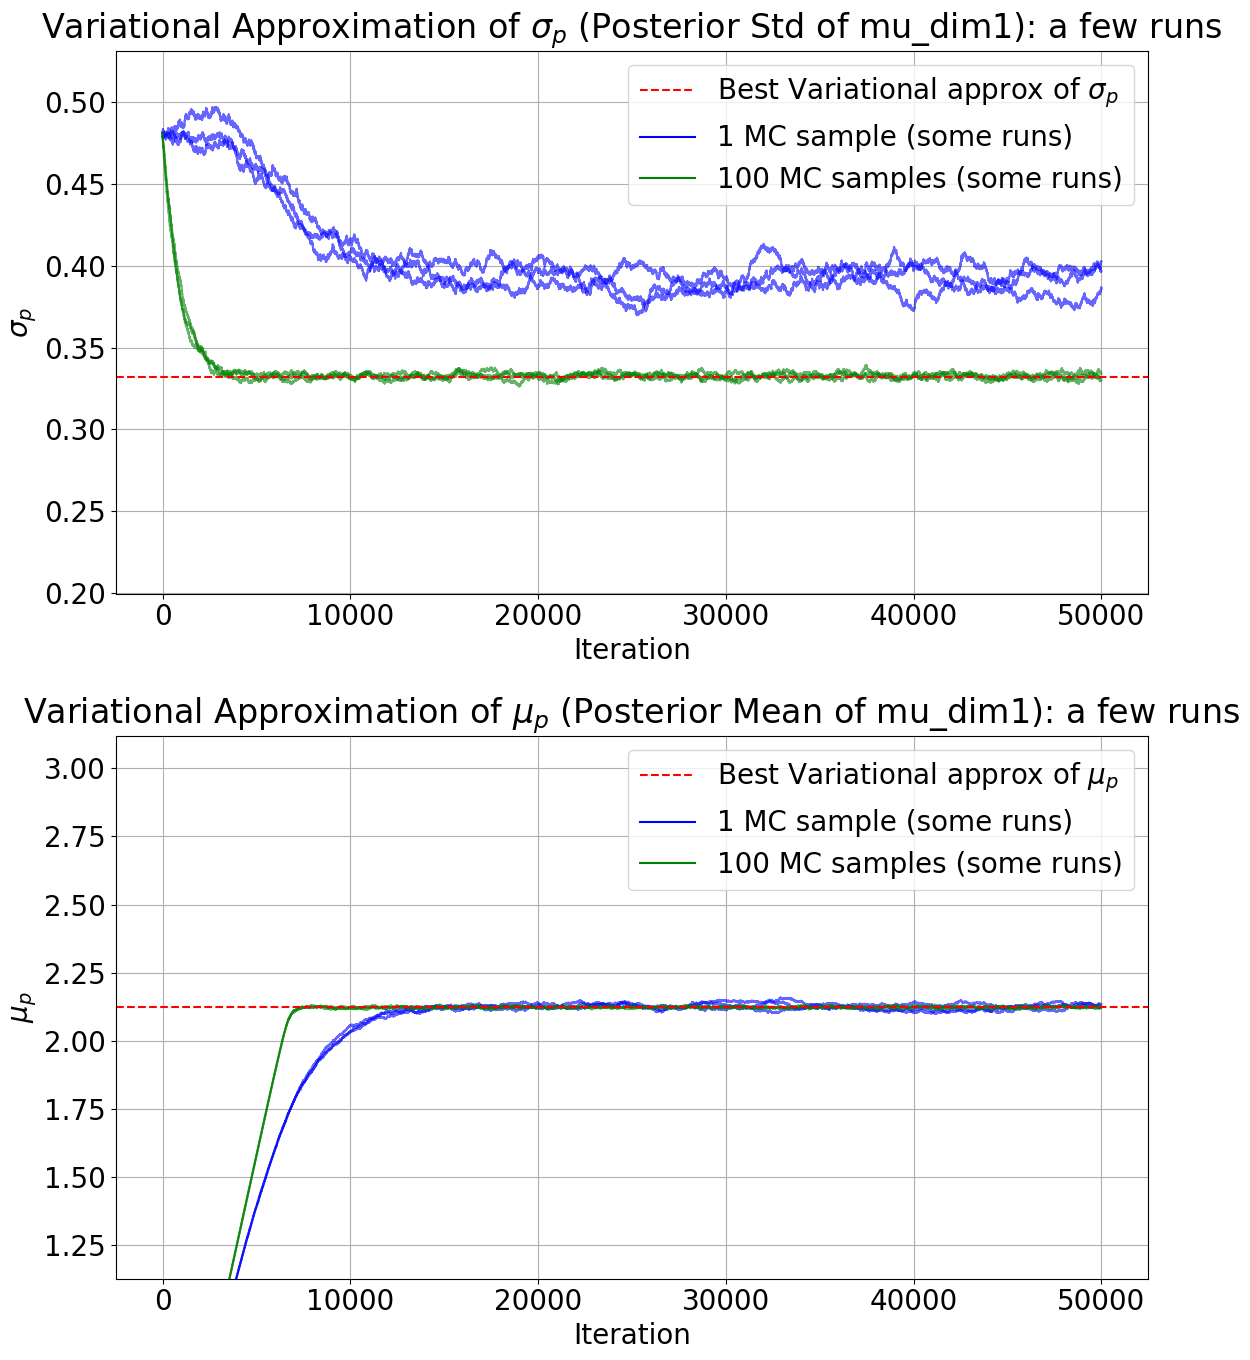

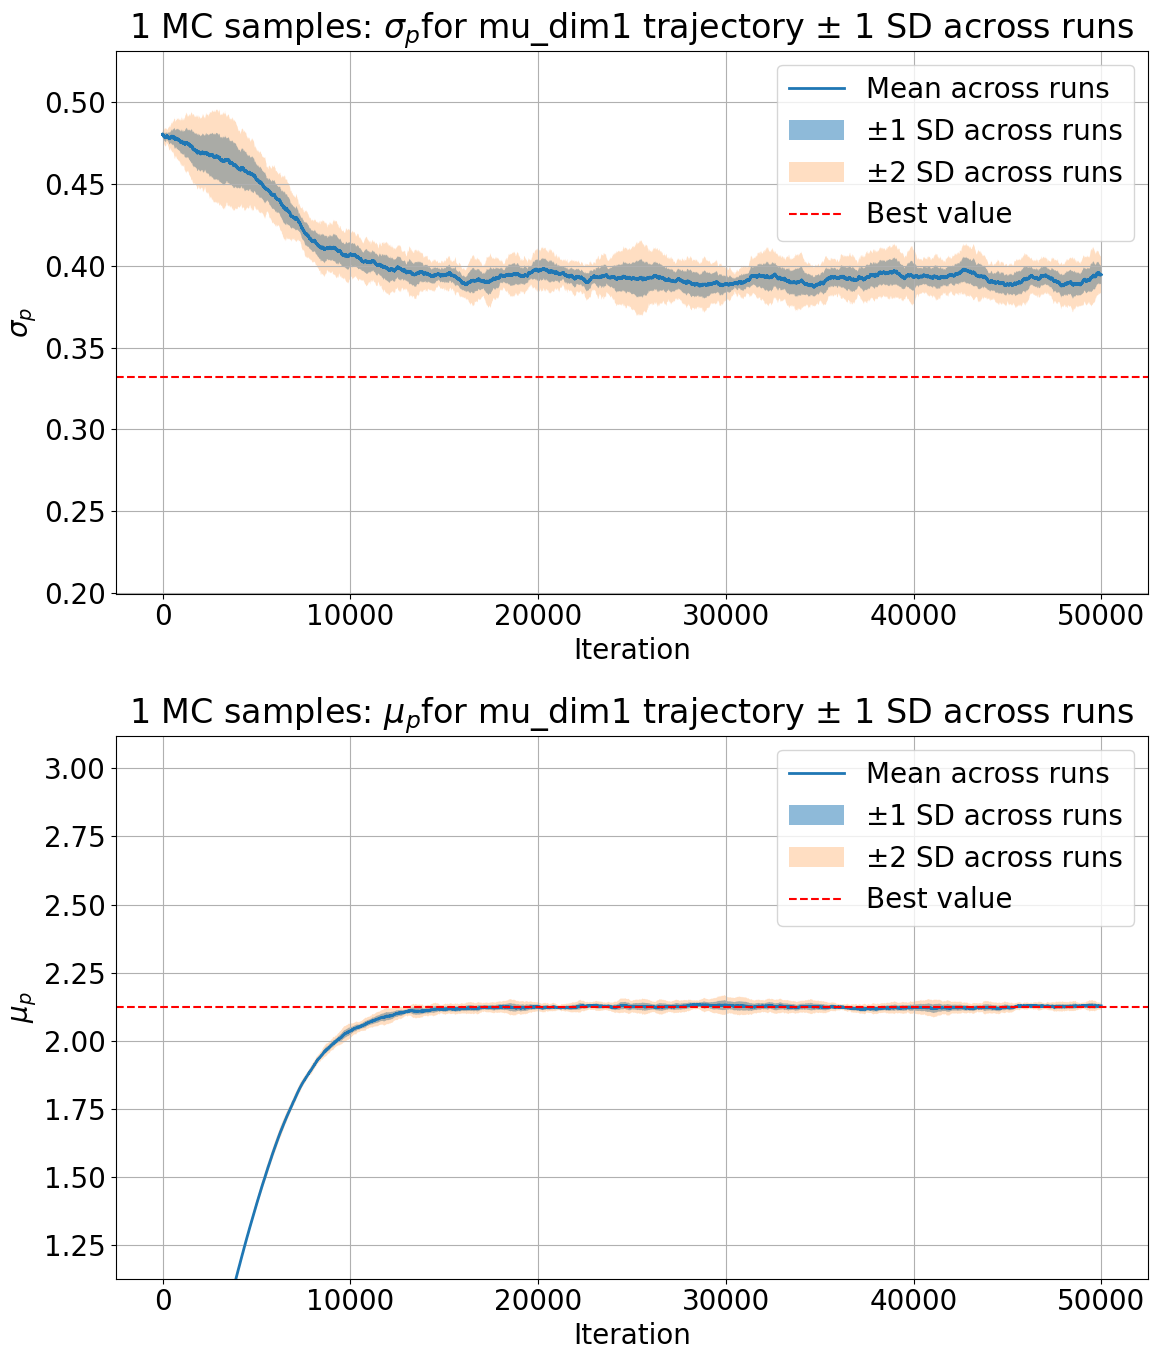

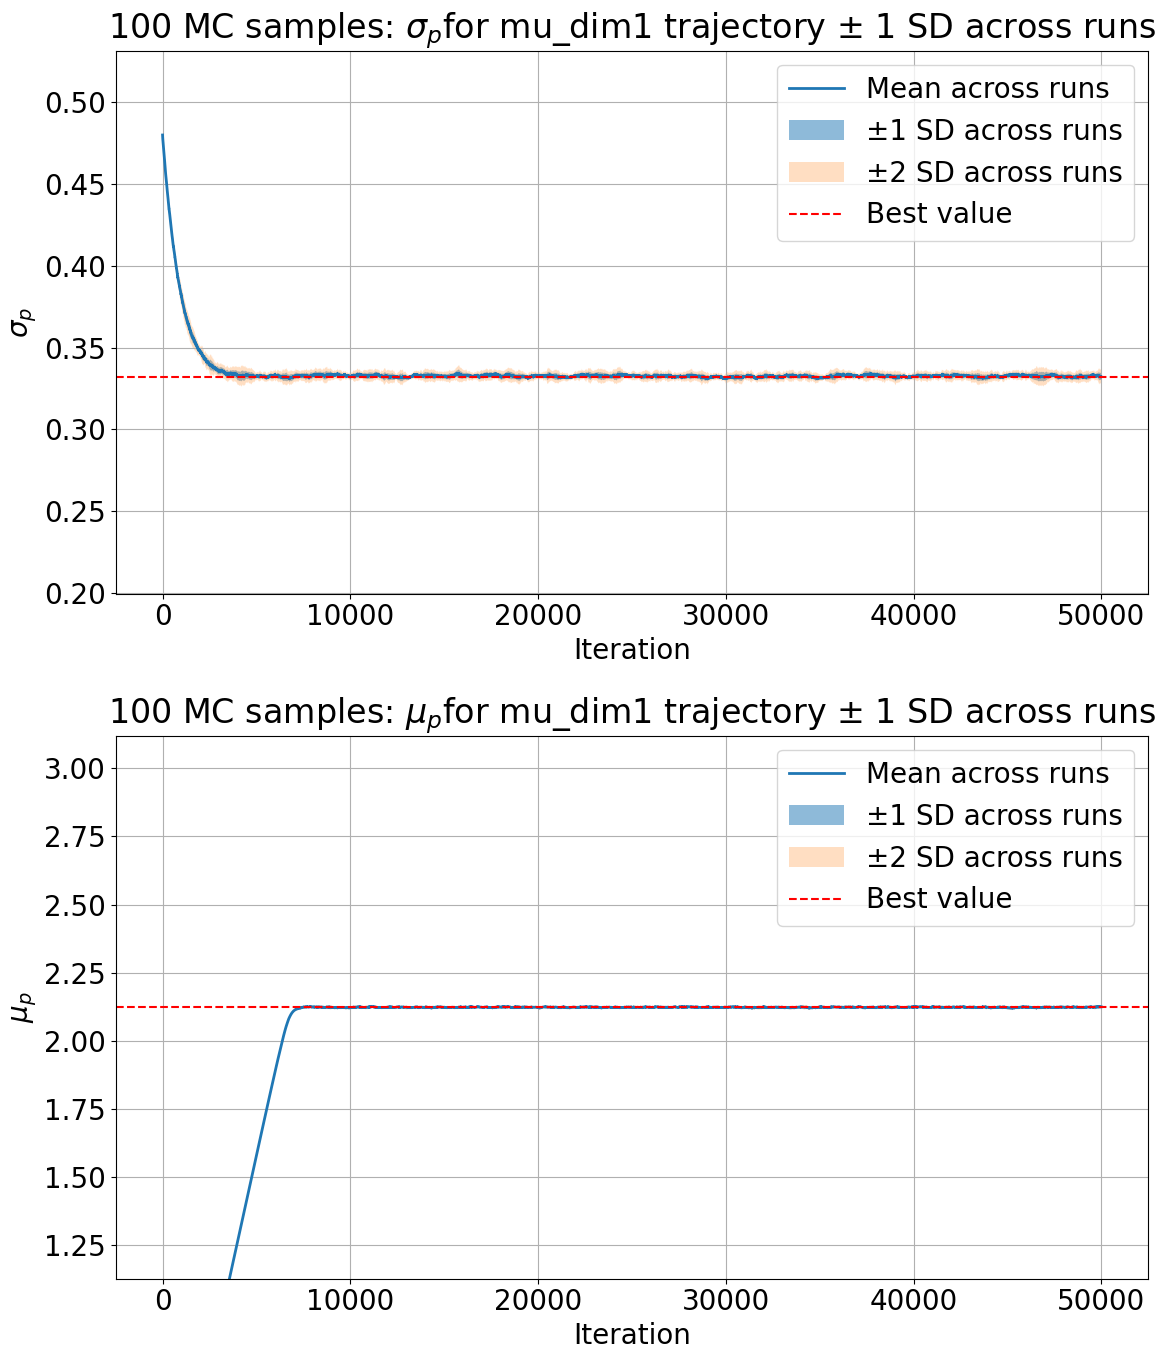

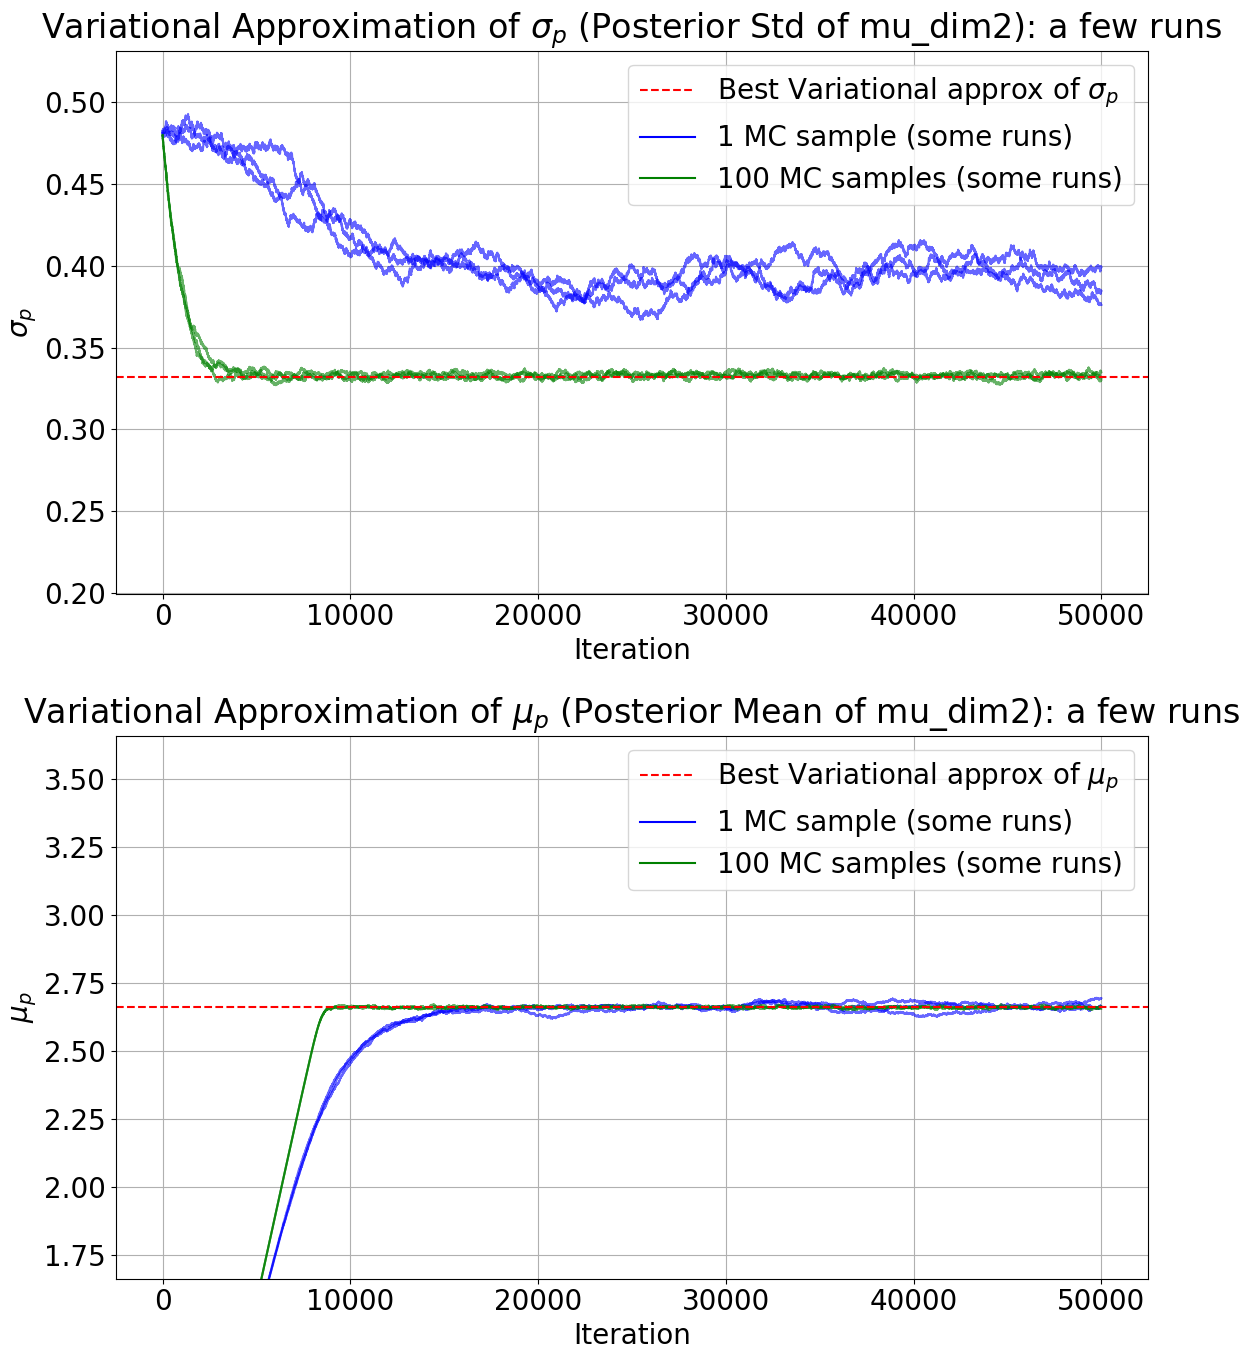

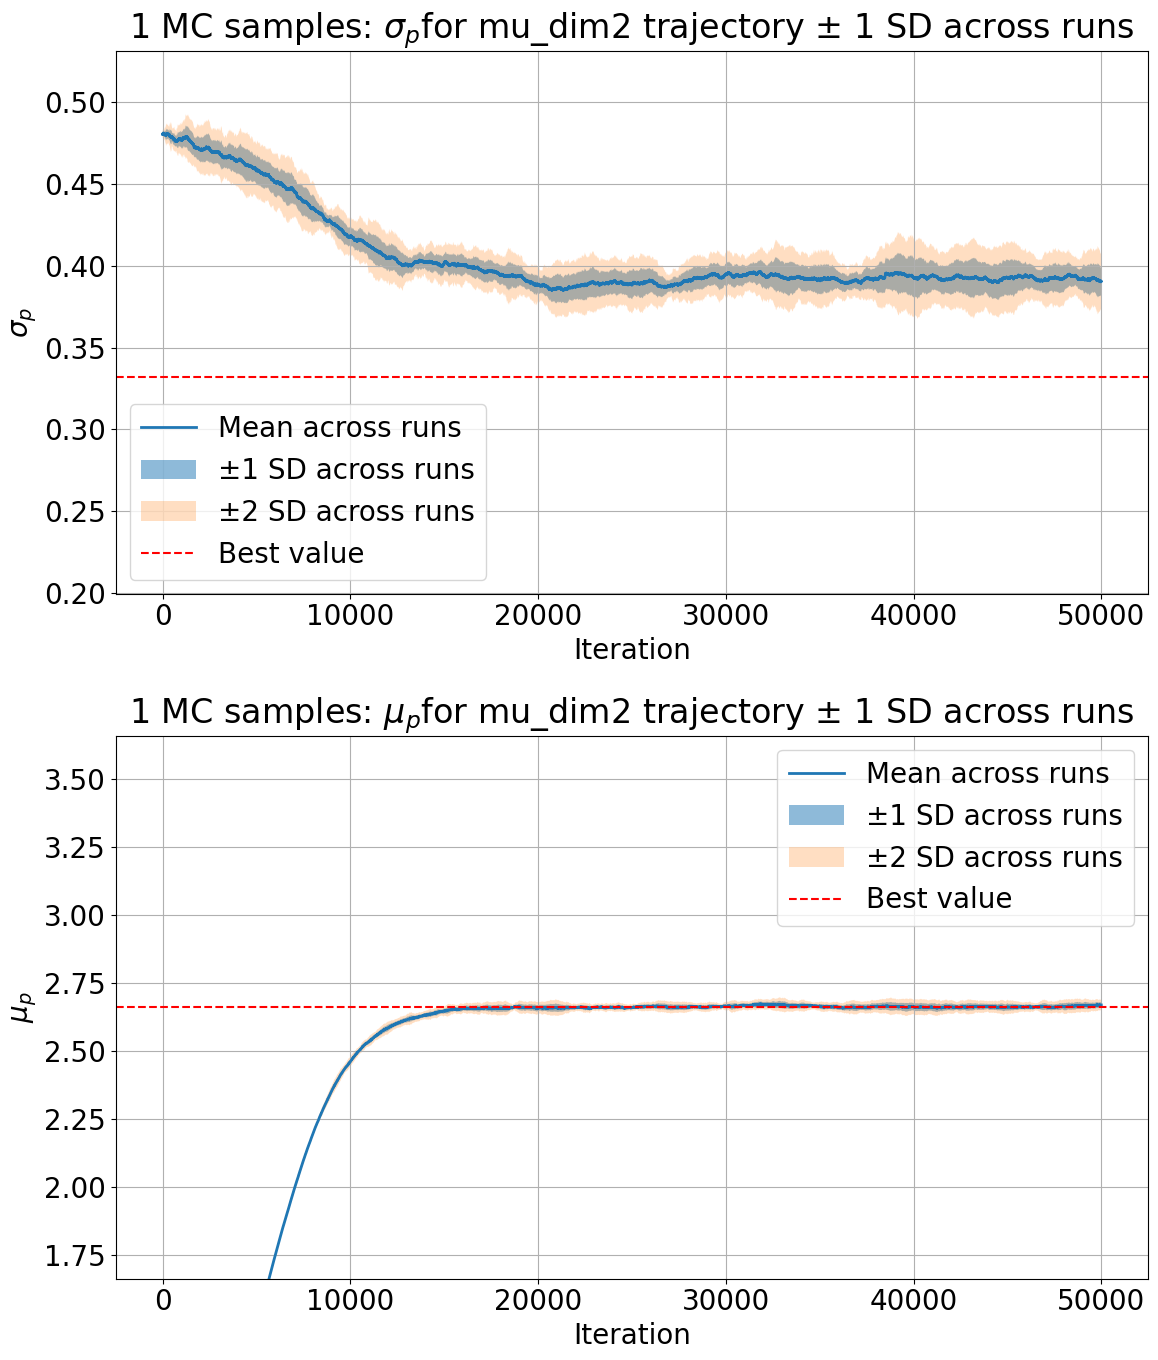

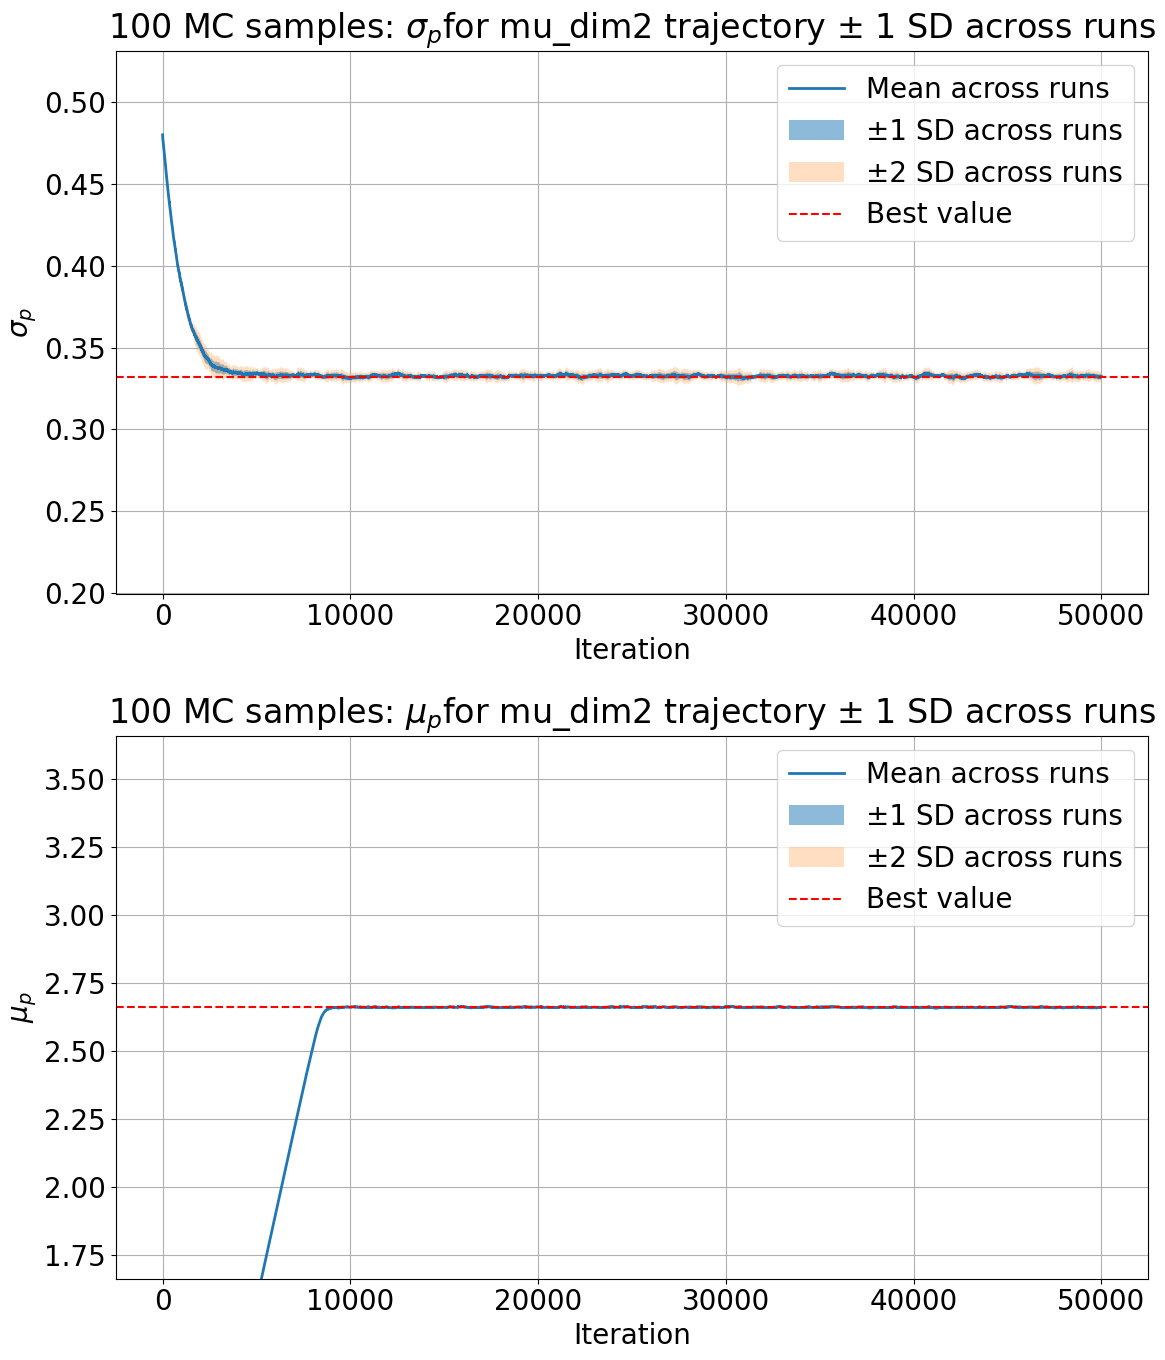

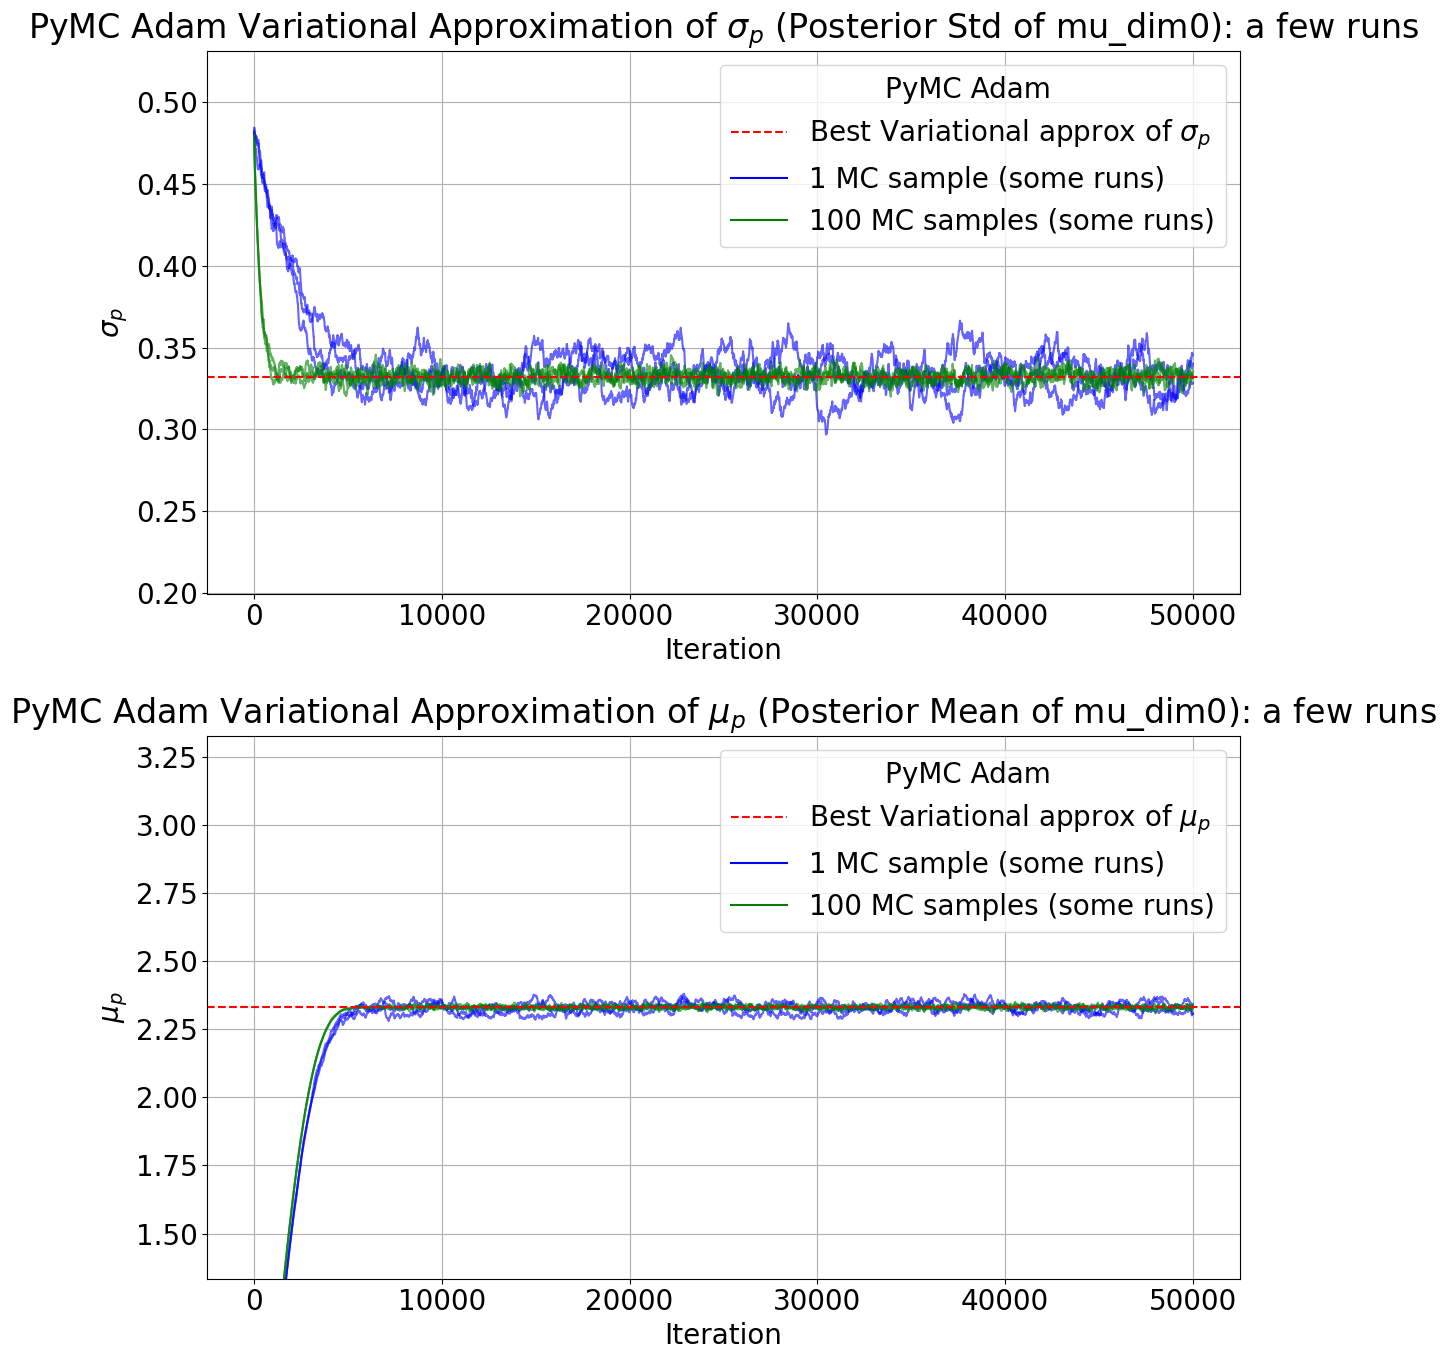

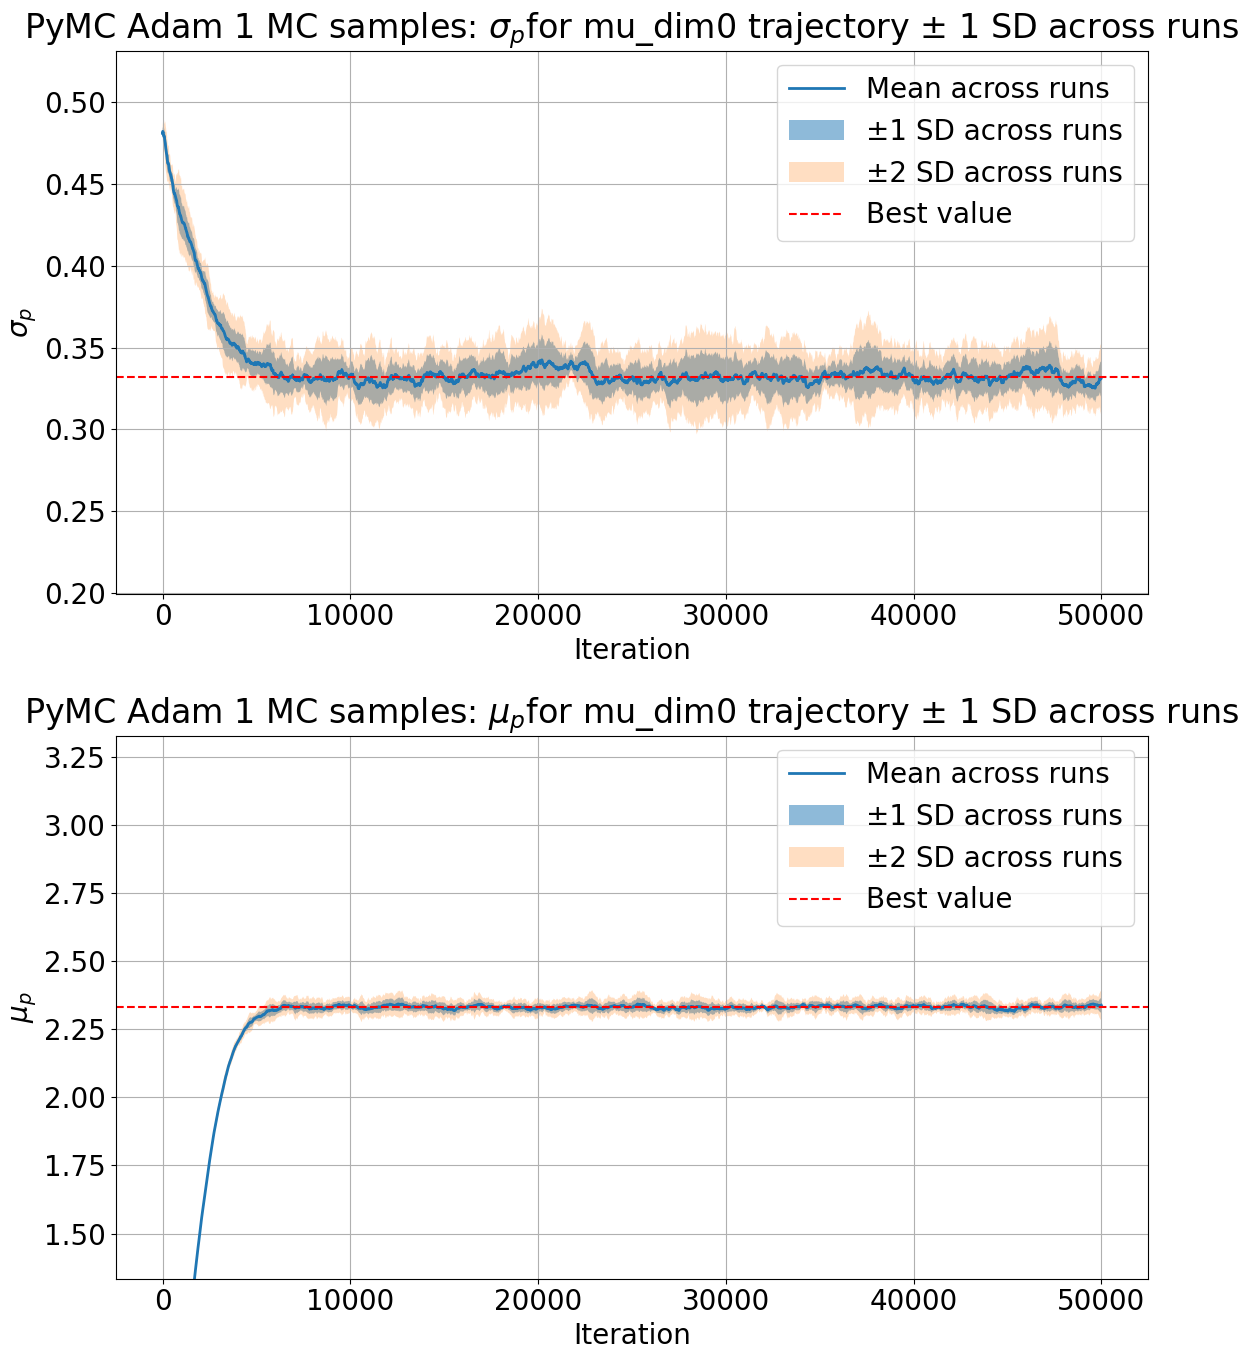

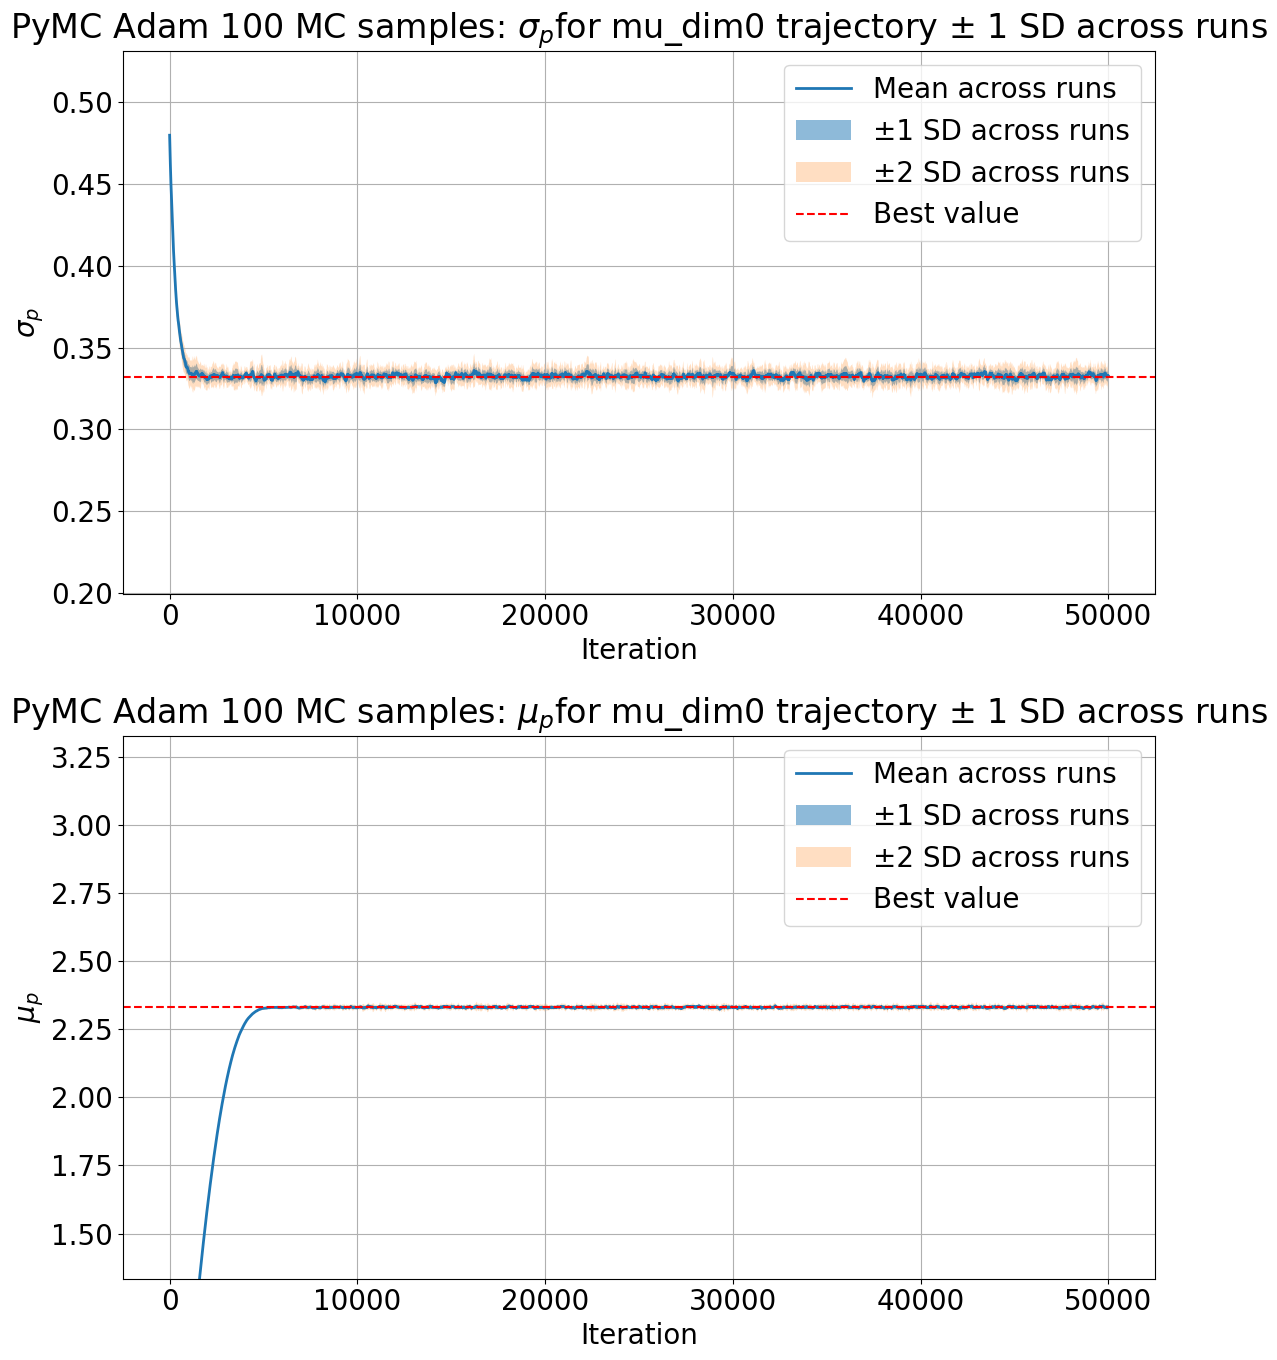

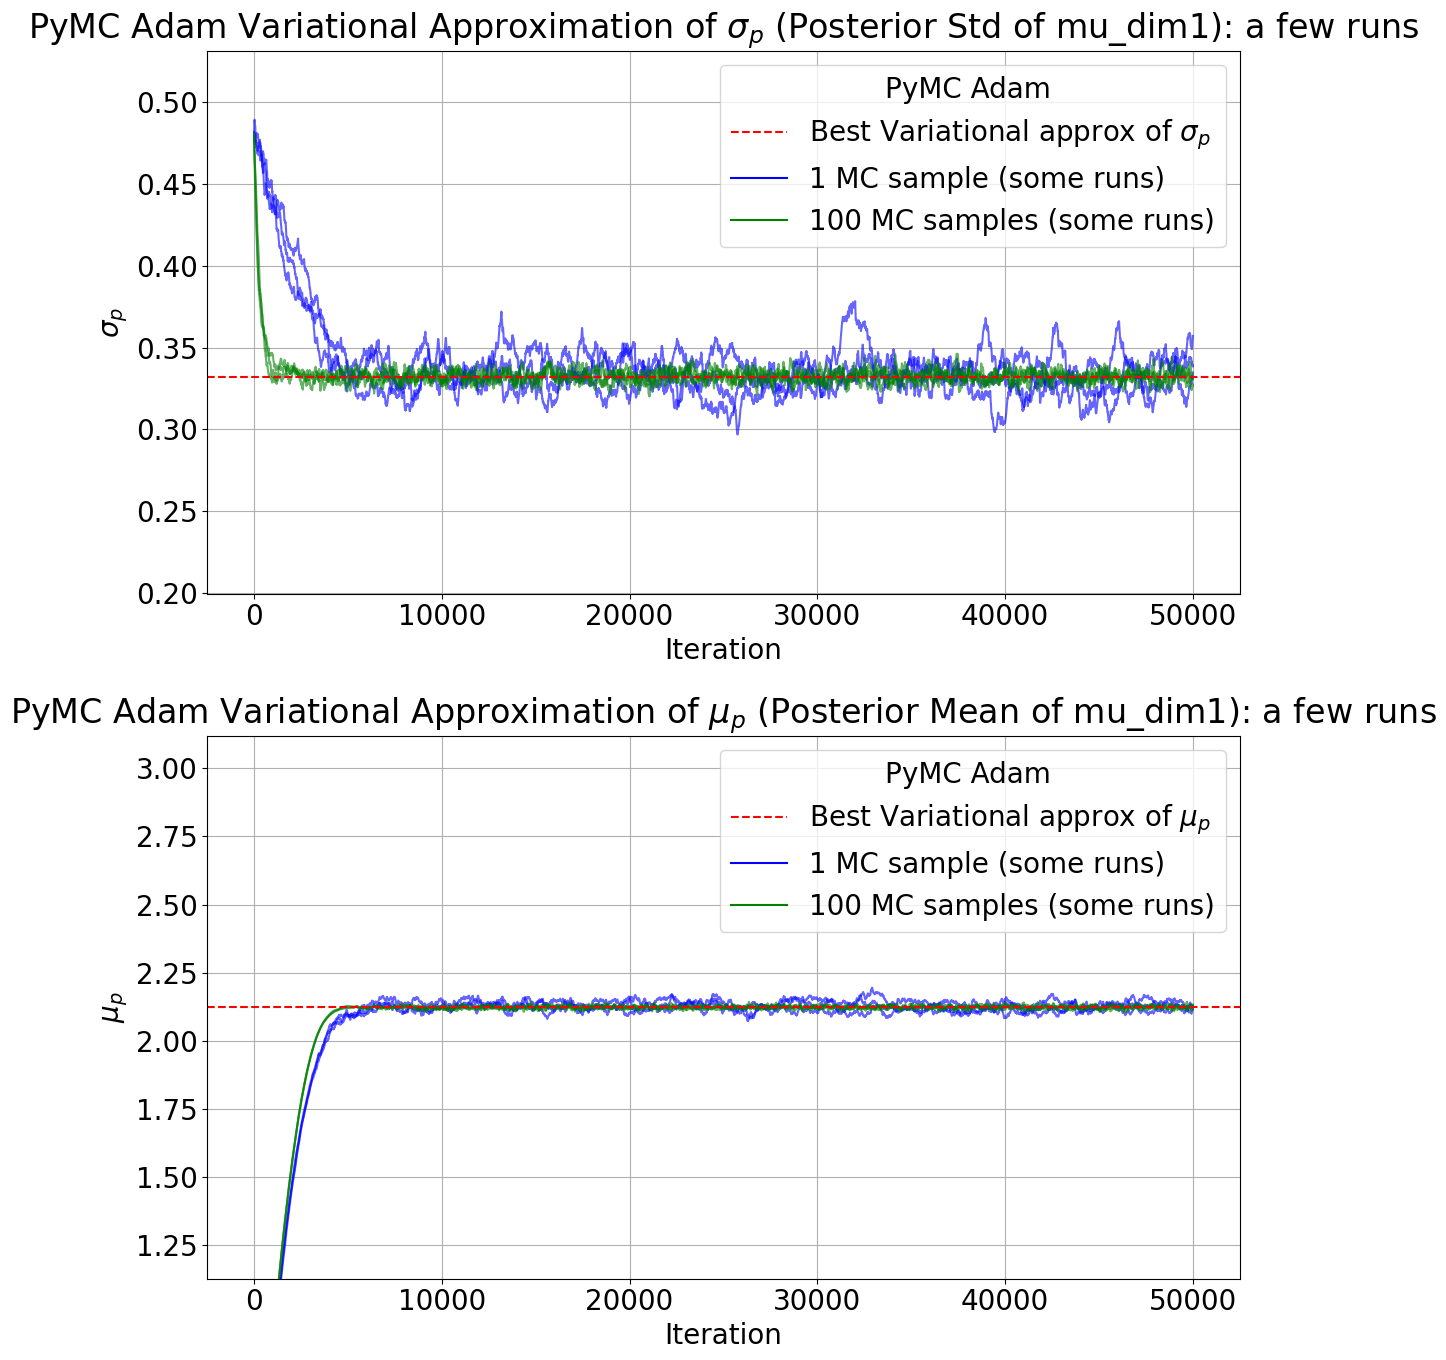

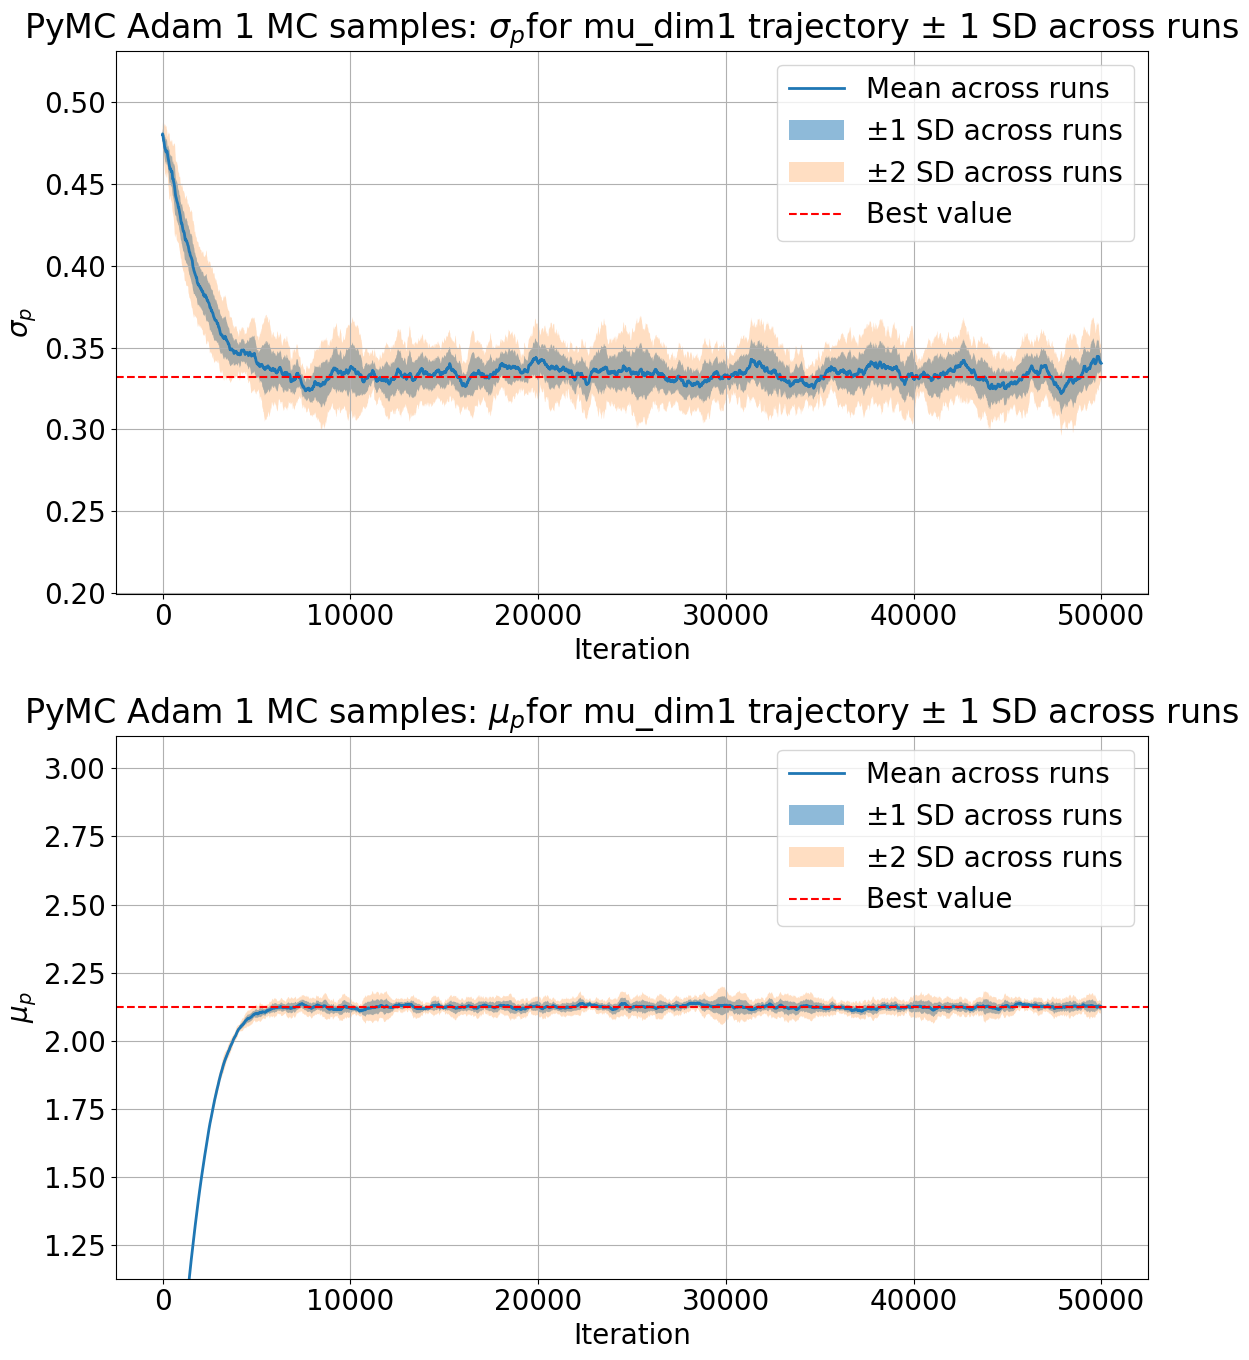

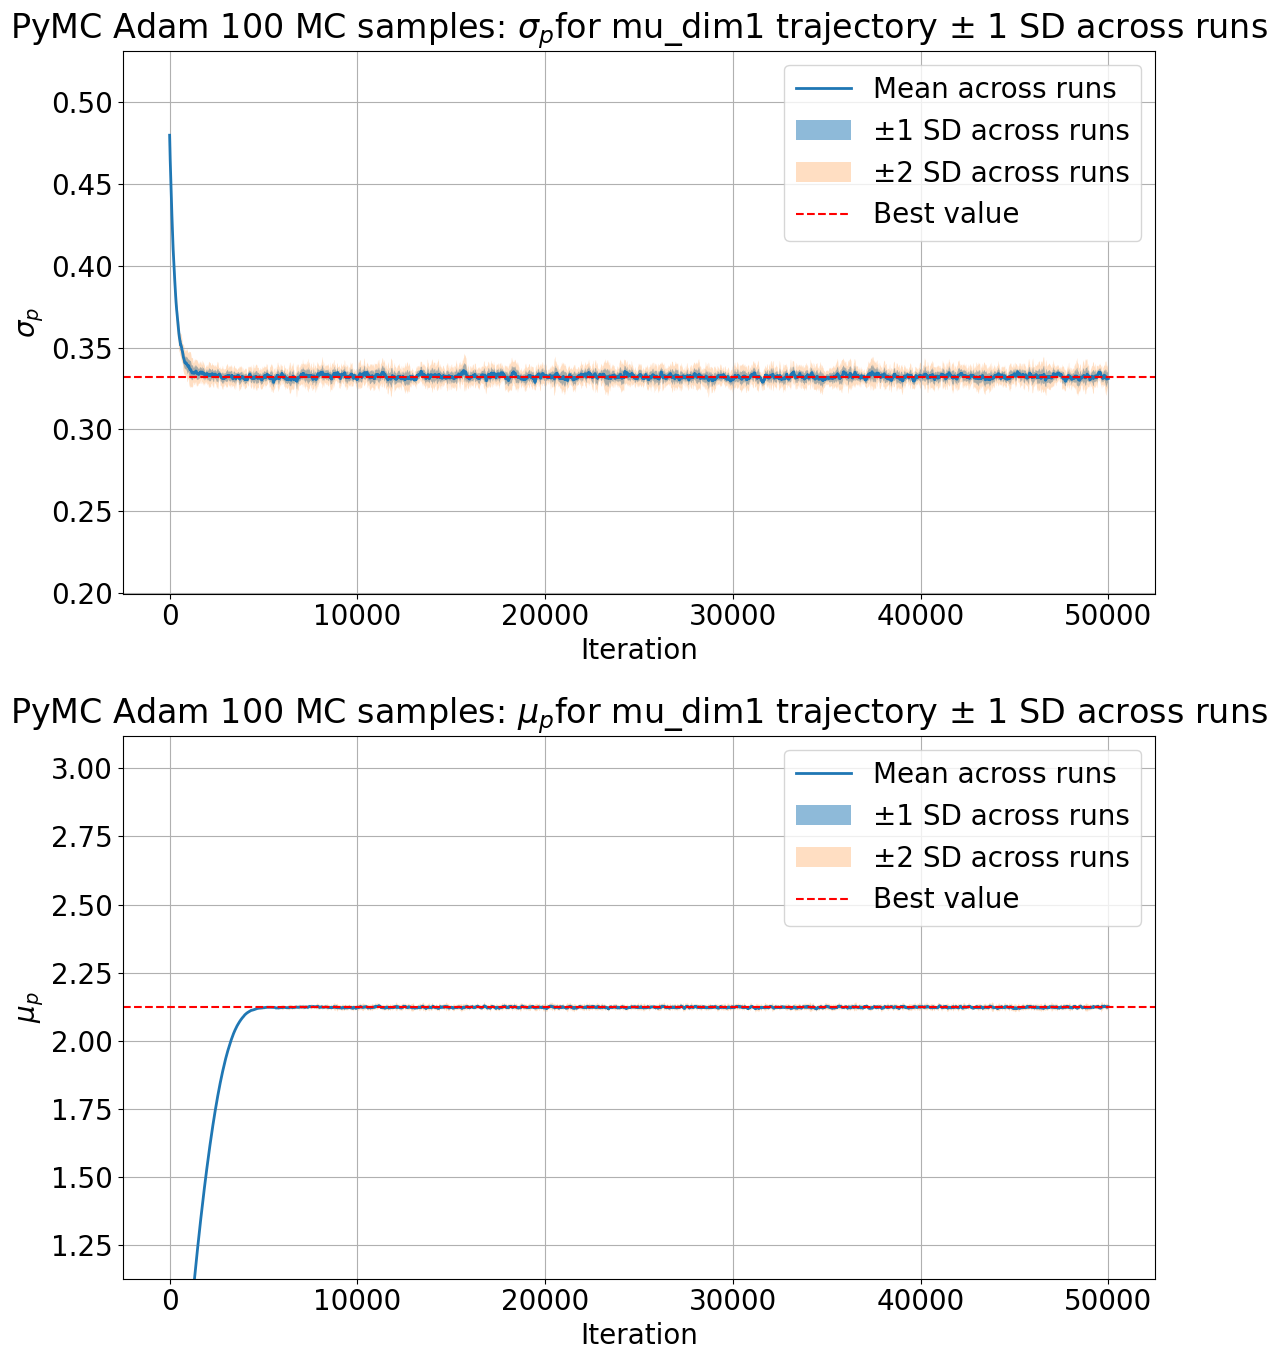

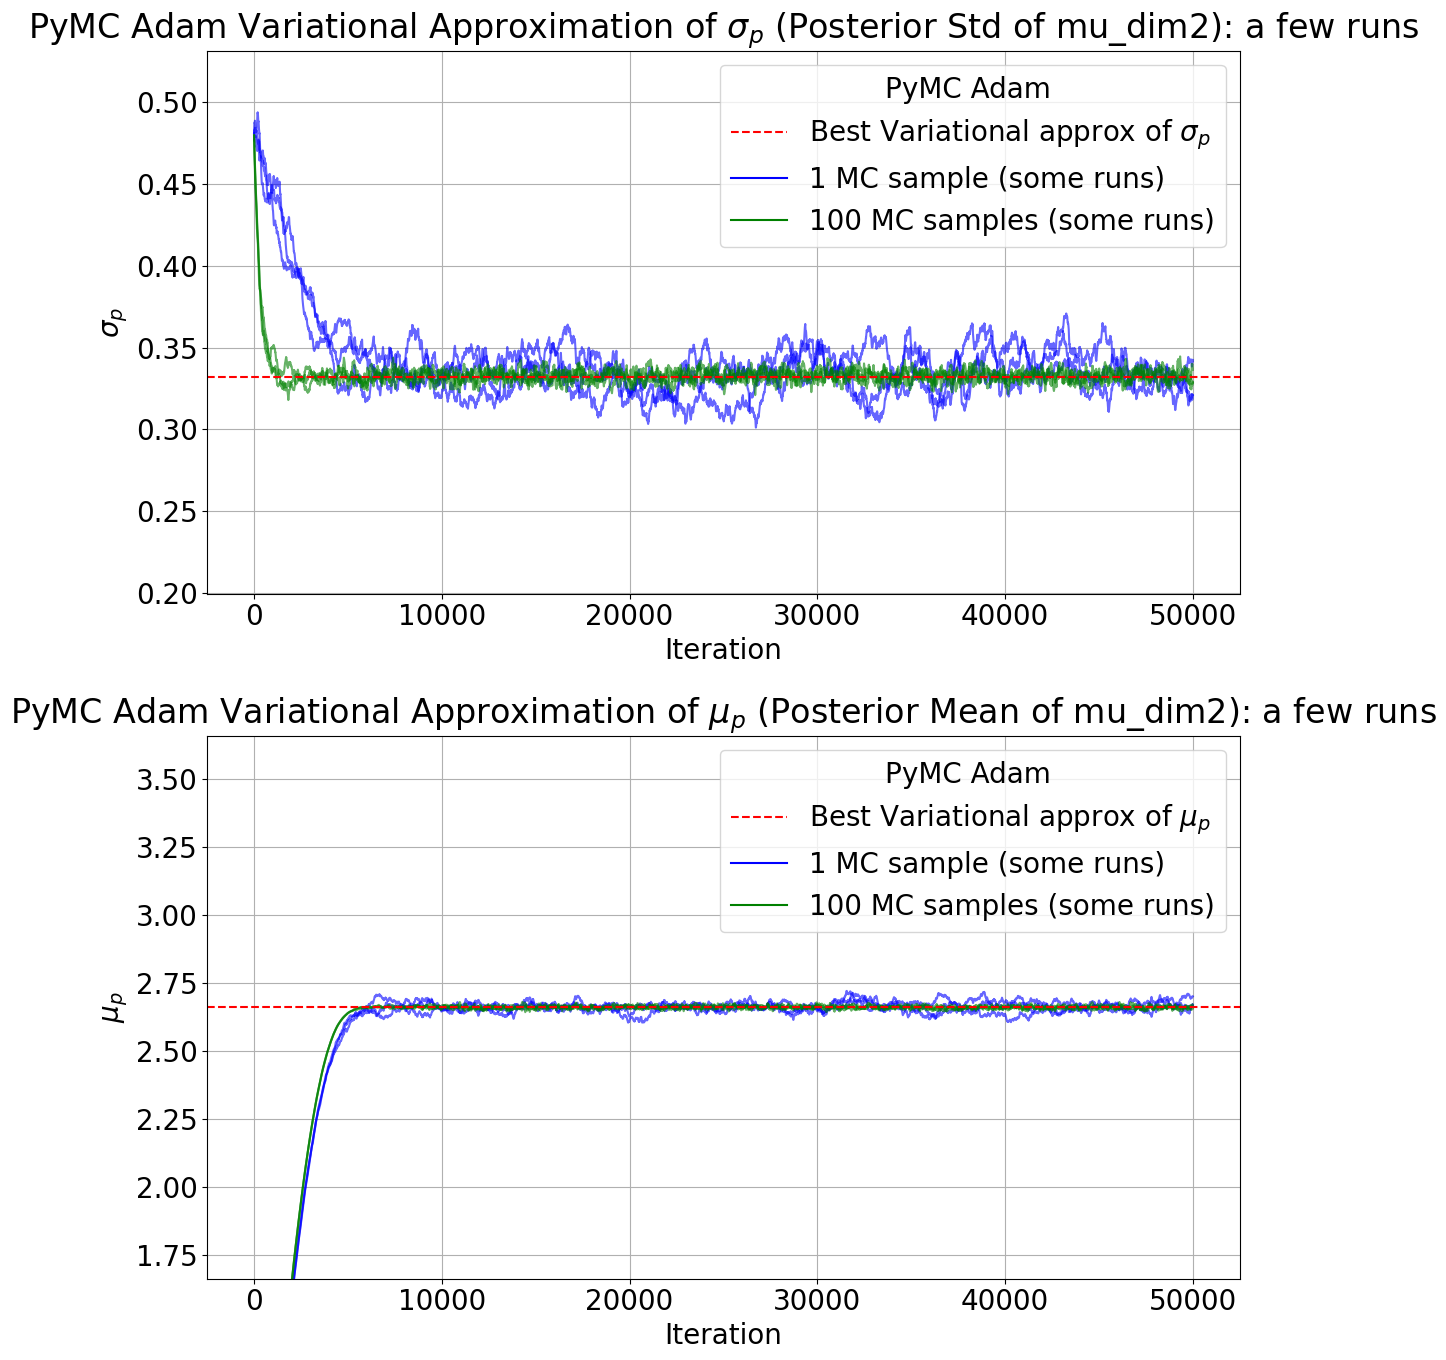

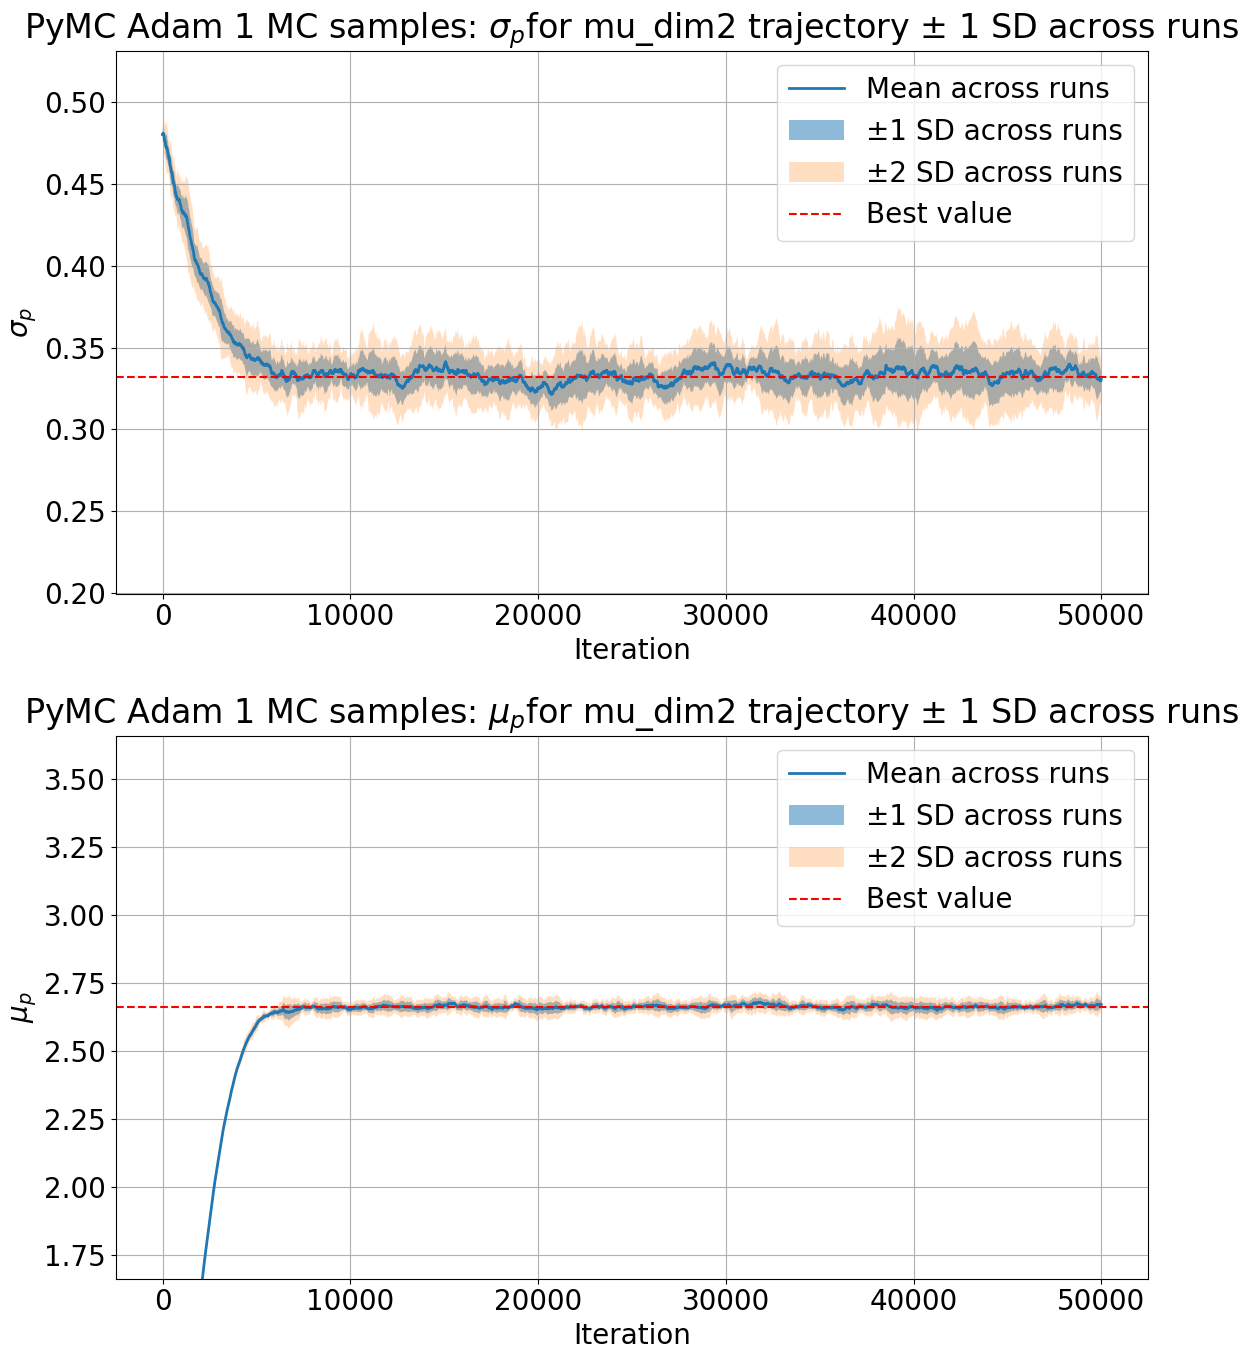

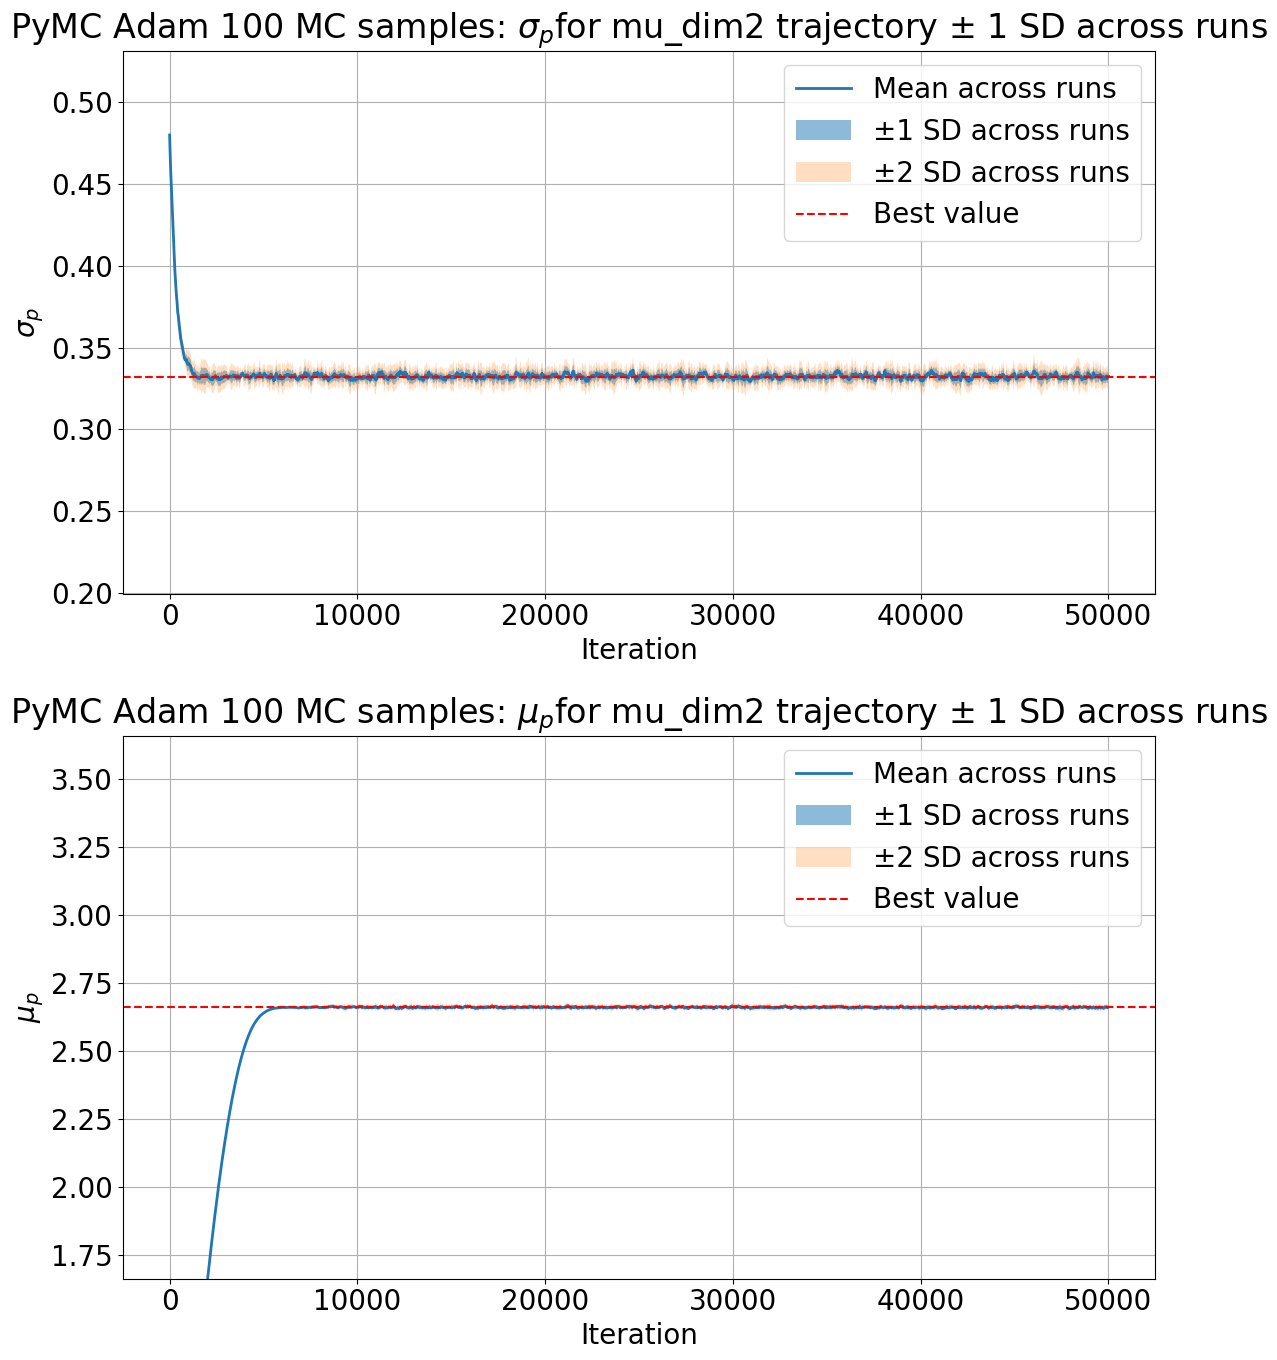

In [7]:

from modulars.plot_rr import plot_some_dims_multid
which_dims = [0, 1, 2]
plot_some_dims_multid(
    single_means, single_covs, multi_means, multi_covs,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3
)

plot_some_dims_multid(
    adam_single_means, adam_single_covs, adam_multi_means, adam_multi_covs,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3, label_prefix='PyMC Adam '
)

In [8]:
single_means.shape

(10, 50000, 40)